In [38]:
import pandas as pd
import seaborn as sb
import numpy as np
import matplotlib.pyplot as plt


In [39]:
df = pd.read_csv("/Users/joshualee/Documents/Sportron/Facebook-Meta-Data/Facebook_AD_Campaign.csv")

In [40]:
df

,ad_id,reporting_start,reporting_end,campaign_id,fb_campaign_id,age,gender,interest1,interest2,interest3,impressions,clicks,spent,total_conversion,approved_conversion
0,708746,17/08/2017,17/08/2017,916,103916,30-34,M,15,17,17,7350.000000,1,1.43,2.0,1.0
1,708749,17/08/2017,17/08/2017,916,103917,30-34,M,16,19,21,17861.000000,2,1.82,2.0,0.0
2,708771,17/08/2017,17/08/2017,916,103920,30-34,M,20,25,22,693.000000,0,0.00,1.0,0.0
3,708815,30/08/2017,30/08/2017,916,103928,30-34,M,28,32,32,4259.000000,1,1.25,1.0,0.0
4,708818,17/08/2017,17/08/2017,916,103928,30-34,M,28,33,32,4133.000000,1,1.29,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,1314410,19/08/2017,19/08/2017,45-49,F,109,111,114,1129773,252,358.189997,13,2.00,NaN,NaN
1139,1314411,19/08/2017,19/08/2017,45-49,F,110,111,116,637549,120,173.880003,3,0.00,NaN,NaN
1140,1314412,19/08/2017,19/08/2017,45-49,F,111,113,117,151531,28,40.289999,2,0.00,NaN,NaN
1141,1314414,17/08/2017,17/08/2017,45-49,F,113,114,117,790253,135,198.710001,8,2.00,NaN,NaN


# Cleaning

In [41]:
df.head()

,ad_id,reporting_start,reporting_end,campaign_id,fb_campaign_id,age,gender,interest1,interest2,interest3,impressions,clicks,spent,total_conversion,approved_conversion
0,708746,17/08/2017,17/08/2017,916,103916,30-34,M,15,17,17,7350.0,1,1.43,2.0,1.0
1,708749,17/08/2017,17/08/2017,916,103917,30-34,M,16,19,21,17861.0,2,1.82,2.0,0.0
2,708771,17/08/2017,17/08/2017,916,103920,30-34,M,20,25,22,693.0,0,0.00,1.0,0.0
3,708815,30/08/2017,30/08/2017,916,103928,30-34,M,28,32,32,4259.0,1,1.25,1.0,0.0
4,708818,17/08/2017,17/08/2017,916,103928,30-34,M,28,33,32,4133.0,1,1.29,1.0,1.0


In [42]:
df.isnull().sum()

ad_id                    0
reporting_start          0
reporting_end            0
campaign_id              0
fb_campaign_id           0
age                      0
gender                   0
interest1                0
interest2                0
interest3                0
impressions              0
clicks                   0
spent                    0
total_conversion       382
approved_conversion    382
dtype: int64

In [43]:
df.dropna(inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 761 entries, 0 to 760
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ad_id                761 non-null    int64  
 1   reporting_start      761 non-null    str    
 2   reporting_end        761 non-null    str    
 3   campaign_id          761 non-null    str    
 4   fb_campaign_id       761 non-null    str    
 5   age                  761 non-null    str    
 6   gender               761 non-null    str    
 7   interest1            761 non-null    int64  
 8   interest2            761 non-null    int64  
 9   interest3            761 non-null    int64  
 10  impressions          761 non-null    float64
 11  clicks               761 non-null    int64  
 12  spent                761 non-null    float64
 13  total_conversion     761 non-null    float64
 14  approved_conversion  761 non-null    float64
dtypes: float64(4), int64(5), str(6)
memory usage: 89.3 

In [44]:
df.describe()

,ad_id,interest1,interest2,interest3,impressions,clicks,spent,total_conversion,approved_conversion
count,7.610000e+02,761.000000,761.000000,761.000000,7.610000e+02,761.000000,761.000000,761.000000,761.000000
mean,8.956389e+05,25.473062,28.977661,28.984231,1.031716e+05,15.340342,25.782181,2.161629,0.768725
std,1.670937e+05,15.508898,15.607548,15.604816,2.462644e+05,32.715738,57.622334,4.062201,1.656445
min,7.087460e+05,2.000000,3.000000,3.000000,8.700000e+01,0.000000,0.000000,0.000000,0.000000
25%,7.480860e+05,16.000000,19.000000,19.000000,3.149000e+03,0.000000,0.000000,1.000000,0.000000
50%,7.811750e+05,22.000000,26.000000,25.000000,1.219300e+04,3.000000,3.580000,1.000000,0.000000
75%,1.121184e+06,29.000000,33.000000,33.000000,8.597000e+04,14.000000,23.210000,2.000000,1.000000
max,1.121593e+06,66.000000,72.000000,72.000000,3.052003e+06,340.000000,639.949998,60.000000,21.000000


In [45]:
index = np.arange(1,762)
df.set_index(index, inplace=True)

In [46]:
df.to_csv('Facebook_cleaned_data.csv', index=False)

# Analyzations.

## Pairplot of the Dataset

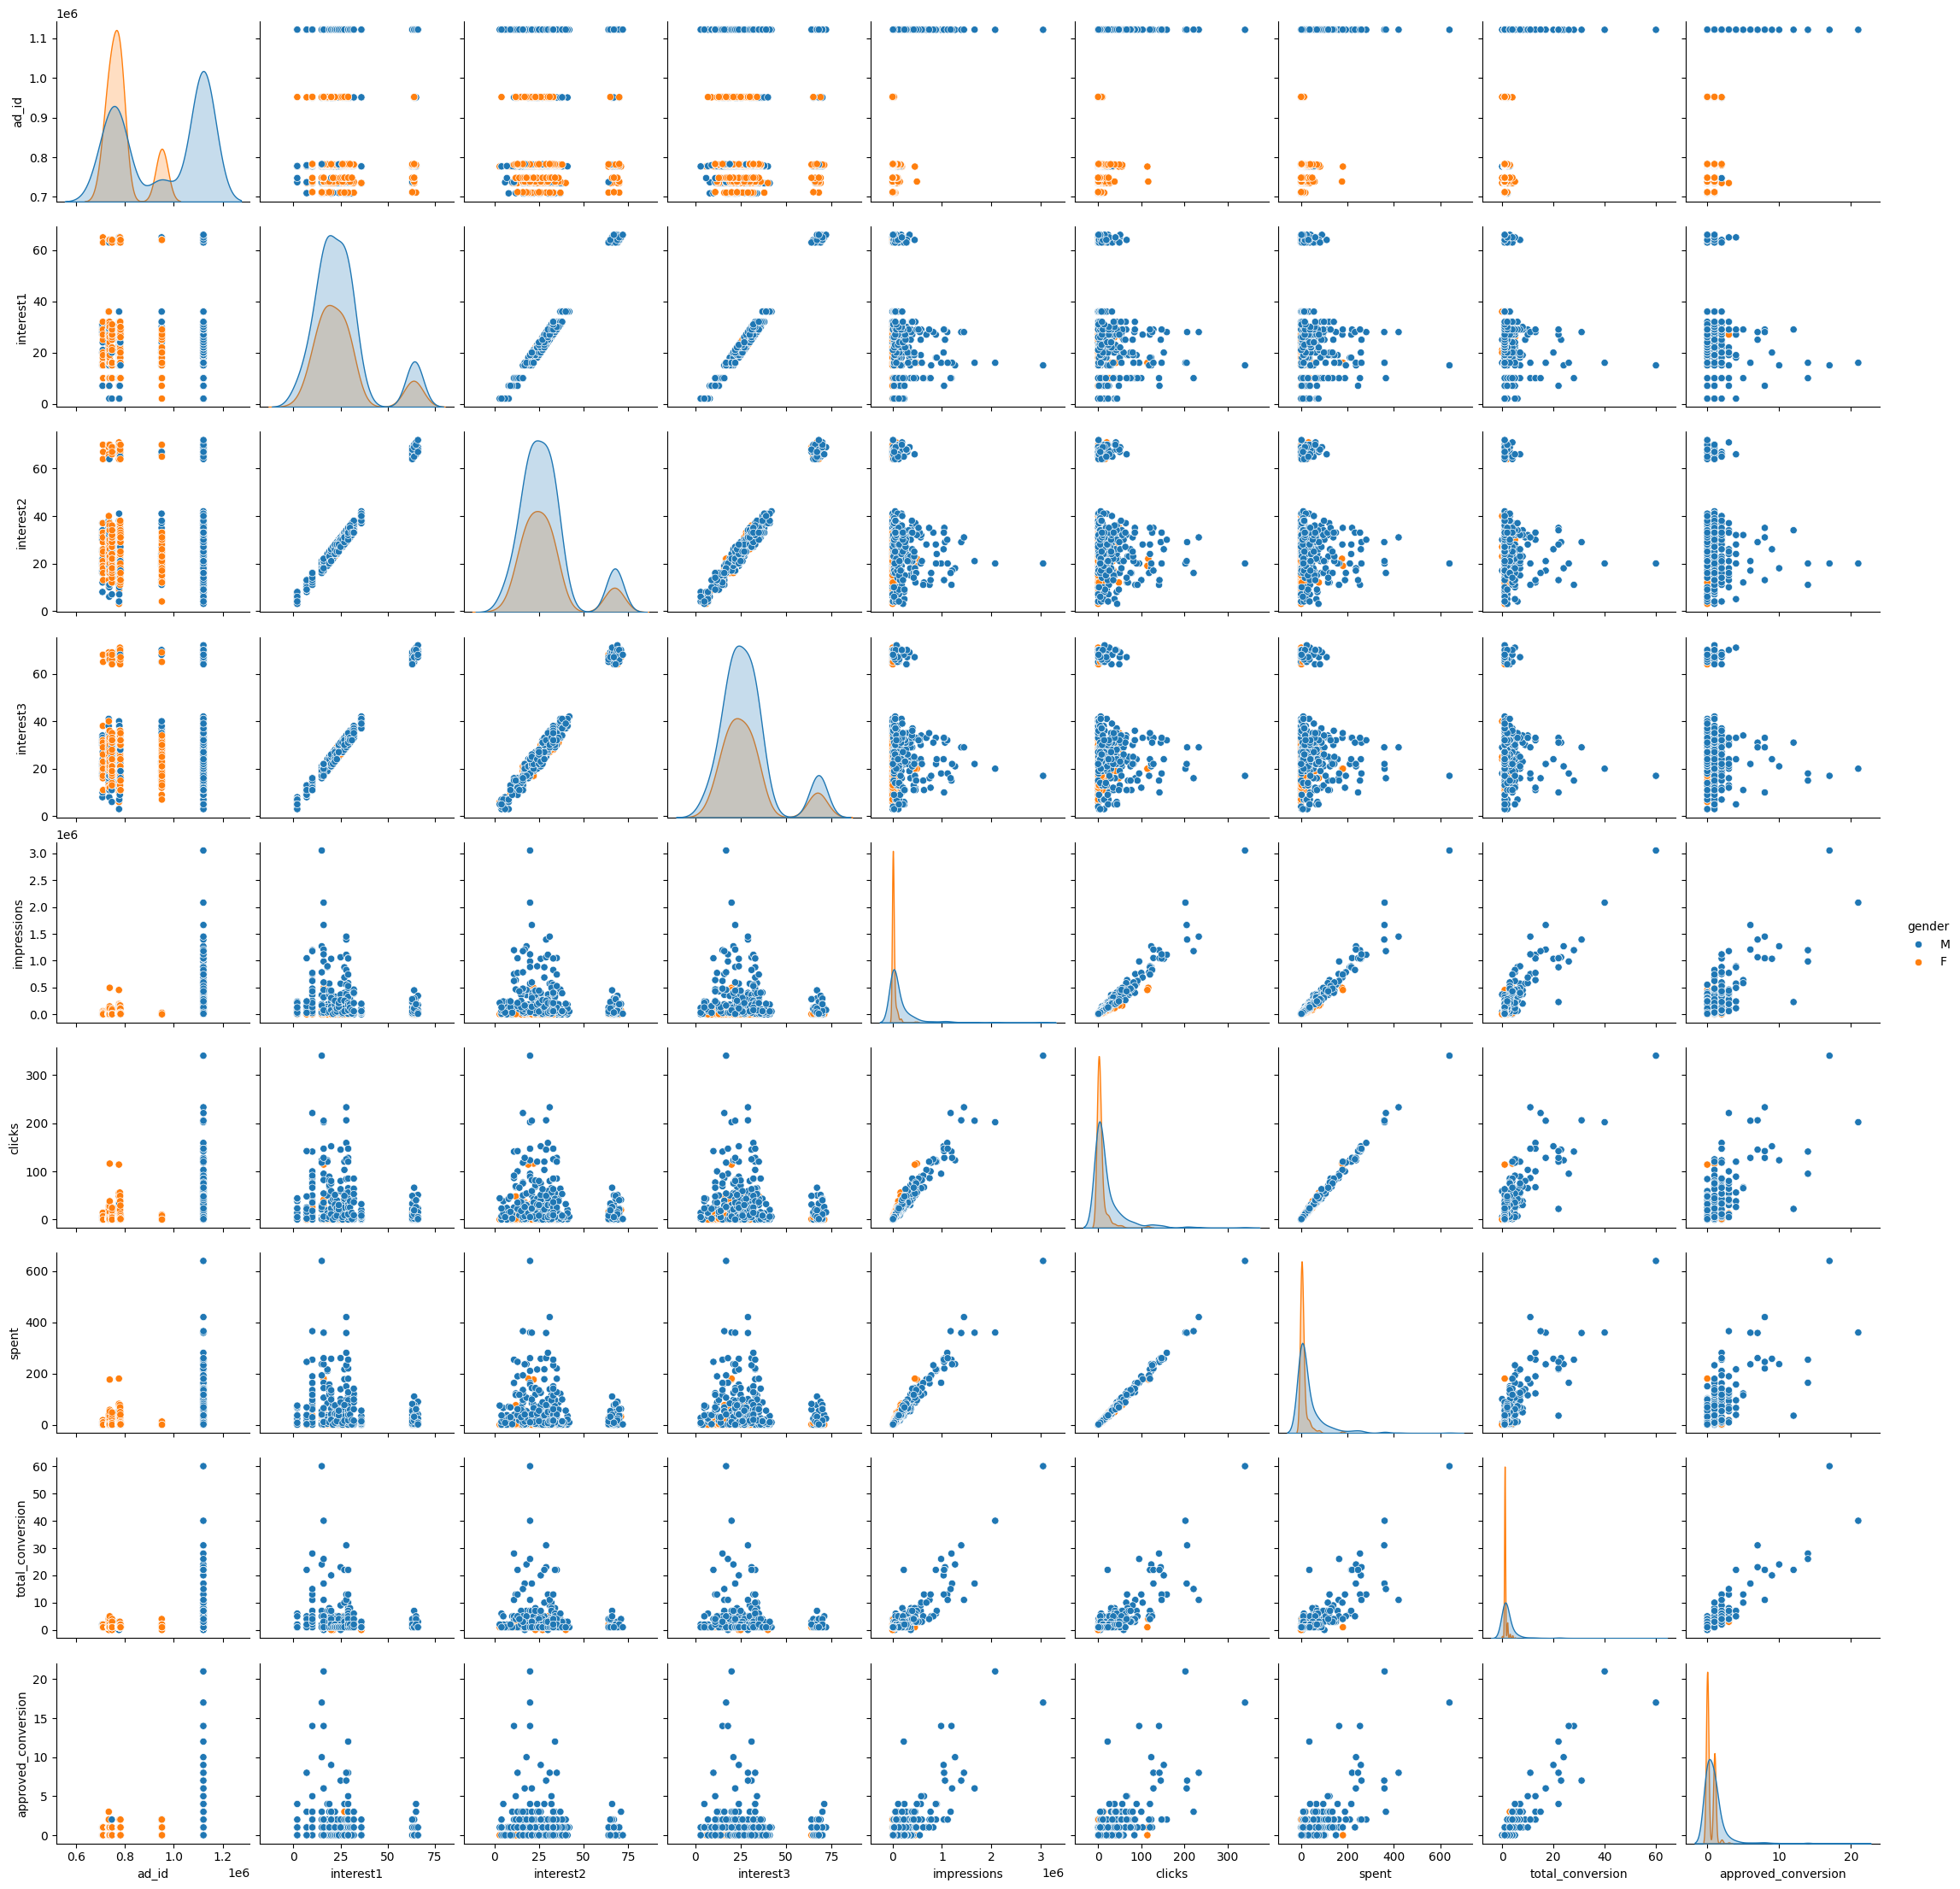

In [47]:
sb.pairplot(df,hue="gender")

## The targetted Age in the Ad Campaign

Text(0.5, 1.0, 'Targetted Age in the Facebook Ad Campaign')

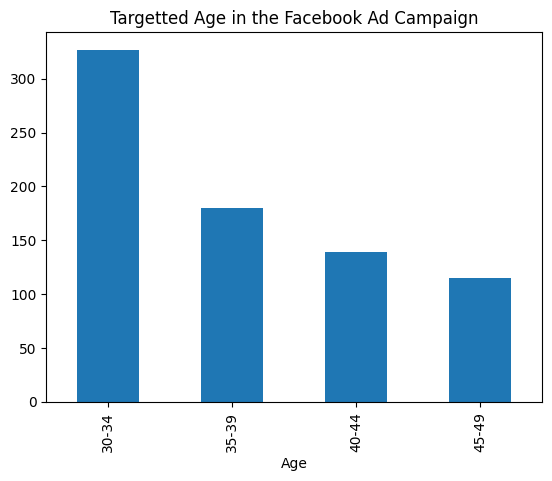

In [48]:
df.age.value_counts().plot(kind='bar')
plt.xlabel("Age")
plt.title("Targetted Age in the Facebook Ad Campaign")

- The Ad Campaignas are mostly made for the age of 30 to 34
- The campaign is least targetted for the middle aged people between 45 to 49

## Correlation throught Heatmap

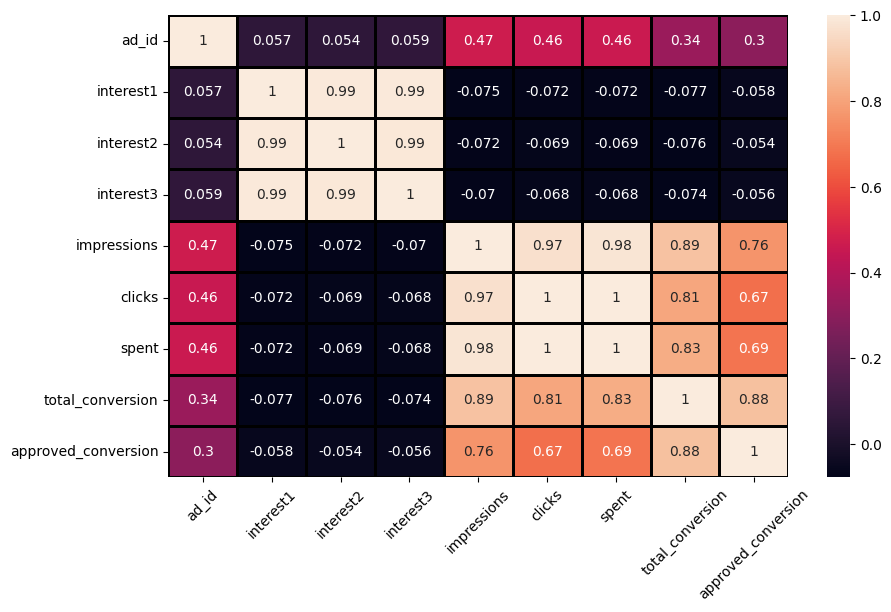

In [49]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10,6))
sb.heatmap(corr, linewidths=1, linecolor='black', annot=True)
plt.xticks(rotation=45)
plt.show()

The correlated values lies between 0.7 and 1

## Genders targetted for the Ad Campaign

In [50]:
df.gender.value_counts()

gender
M    486
F    275
Name: count, dtype: int64

The Ads are targetted mainly for the Men as it is around 2x that of Female

## Finding out who spent the maximum on Ad Campaign

In [51]:
df[df["spent"] == df["spent"].max()]

,ad_id,reporting_start,reporting_end,campaign_id,fb_campaign_id,age,gender,interest1,interest2,interest3,impressions,clicks,spent,total_conversion,approved_conversion
526,1121100,29/08/2017,29/08/2017,1178,144532,30-34,M,15,20,17,3052003.0,340,639.949998,60.0,17.0


The Maximum amount spent on Ads is around 640

## Maximum number of clicks received by an ID

In [52]:
df[df["clicks"] == df["clicks"].max()]

,ad_id,reporting_start,reporting_end,campaign_id,fb_campaign_id,age,gender,interest1,interest2,interest3,impressions,clicks,spent,total_conversion,approved_conversion
526,1121100,29/08/2017,29/08/2017,1178,144532,30-34,M,15,20,17,3052003.0,340,639.949998,60.0,17.0


ID 1178 has recieved the maximum number of clicks of 350 by spending around 640

## Total conversions by each ID

In [53]:
tc = (df.groupby(["campaign_id"])).total_conversion.sum()
tc

campaign_id
1178    1050.0
916       58.0
936      537.0
Name: total_conversion, dtype: float64

ID 1178 has received the maximum number of conversions of 1050

## Total Approved conversions by each ID

In [54]:
ac = (df.groupby(["campaign_id"])).approved_conversion.sum()
ac

campaign_id
1178    378.0
916      24.0
936     183.0
Name: approved_conversion, dtype: float64

ID 1178 has recieved the maximum number of approved conversions of 378

## Percentage of Ads approved

In [55]:
percent_approved = (ac/tc)*100
percent_approved

campaign_id
1178    36.000000
916     41.379310
936     34.078212
dtype: float64

ID 916 has received the highest percentage number of approved conversions of 41.38%

## Finding out total amount spent of Ads

In [56]:
(df.groupby(['campaign_id'])).spent.sum()

campaign_id
1178    16577.159998
916       149.710001
936      2893.369999
Name: spent, dtype: float64

ID 936 has spent the highest with 296936.80

## Total Number of impressions received

In [57]:
(df.groupby(['campaign_id'])).impressions.sum()


campaign_id
1178    69902476.0
916       482925.0
936      8128187.0
Name: impressions, dtype: float64

ID 1178 has received the highest number of impressions of 69902476

## Total Number of clicks received

In [58]:
(df.groupby(['campaign_id'])).clicks.sum()

campaign_id
1178    9577
916      113
936     1984
Name: clicks, dtype: int64

ID 1178 has received the highest number of impressions of 9577

# Cross Validation

In [59]:
df.columns.tolist()

['ad_id',
 'reporting_start',
 'reporting_end',
 'campaign_id',
 'fb_campaign_id',
 'age',
 'gender',
 'interest1',
 'interest2',
 'interest3',
 'impressions',
 'clicks',
 'spent',
 'total_conversion',
 'approved_conversion']

In [60]:
df["spent"].dtypes

dtype('float64')

In [74]:
features = [
    "clicks",
    "impressions",
    "total_conversion",
    "approved_conversion"
]

In [75]:
X = df[features]
y = df['spent']
X.dtypes

clicks                   int64
impressions            float64
total_conversion       float64
approved_conversion    float64
dtype: object

In [76]:
for col in X.columns:
    if X[col].astype(str).str.contains("/").any():
        print("Possible date column:", col)

In [77]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="r2"   # regression metric
)

print(scores)
print("Mean R²:", scores.mean())

[0.99173527 0.99361968 0.97859541 0.99778996 0.99429076]
Mean R²: 0.9912062164078452


In [78]:
X.corrwith(y).sort_values(ascending=False)

clicks                 0.997355
impressions            0.980036
total_conversion       0.825692
approved_conversion    0.687713
dtype: float64

# Regression Analysis

In [26]:
df

,ad_id,reporting_start,reporting_end,campaign_id,fb_campaign_id,age,gender,interest1,interest2,interest3,impressions,clicks,spent,total_conversion,approved_conversion
1,708746,17/08/2017,17/08/2017,916,103916,30-34,M,15,17,17,7350.0,1,1.430000,2.0,1.0
2,708749,17/08/2017,17/08/2017,916,103917,30-34,M,16,19,21,17861.0,2,1.820000,2.0,0.0
3,708771,17/08/2017,17/08/2017,916,103920,30-34,M,20,25,22,693.0,0,0.000000,1.0,0.0
4,708815,30/08/2017,30/08/2017,916,103928,30-34,M,28,32,32,4259.0,1,1.250000,1.0,0.0
5,708818,17/08/2017,17/08/2017,916,103928,30-34,M,28,33,32,4133.0,1,1.290000,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
757,1121585,20/08/2017,20/08/2017,1178,144621,40-44,M,66,72,68,9773.0,1,1.460000,1.0,0.0
758,1121589,20/08/2017,20/08/2017,1178,144622,45-49,M,10,16,11,464036.0,77,123.550000,3.0,1.0
759,1121590,20/08/2017,20/08/2017,1178,144622,45-49,M,10,16,15,478480.0,75,135.750001,3.0,1.0
760,1121592,20/08/2017,20/08/2017,1178,144622,45-49,M,10,14,11,428812.0,66,116.880000,4.0,2.0


In [79]:
X=df[features]
y=df[['spent']]

In [80]:
from sklearn.model_selection import train_test_split

In [81]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [82]:
from sklearn.linear_model import LinearRegression
lr= LinearRegression()
lr

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [86]:
lr.fit(X_train, y_train)
pred = lr.predict(X_test)

In [84]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,pred)
r2


0.9968804805817139

In [89]:
new_data = [[4, 5000, 2, 1]]
lr.predict(new_data)

/Users/joshualee/Documents/Sportron/Facebook-Meta-Data/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[4.71399083]])

In [90]:
df[features].describe()

,clicks,impressions,total_conversion,approved_conversion
count,761.000000,7.610000e+02,761.000000,761.000000
mean,15.340342,1.031716e+05,2.161629,0.768725
std,32.715738,2.462644e+05,4.062201,1.656445
min,0.000000,8.700000e+01,0.000000,0.000000
25%,0.000000,3.149000e+03,1.000000,0.000000
50%,3.000000,1.219300e+04,1.000000,0.000000
75%,14.000000,8.597000e+04,2.000000,1.000000
max,340.000000,3.052003e+06,60.000000,21.000000


Conclusion: The amount spent is related to the conversions, the more you spent, the more you get reach